IMPORT LIBRARIES 

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

Load Dataset

In [2]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

Data Expoloration

In [3]:
df.shape

(1200, 14)

In [4]:
df.head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NaN,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [6]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()  

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Data Cleaning

In [9]:
df["CouponCode"] = df["CouponCode"].replace("nan", np.nan)
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

CREATE SQLITE DATABASE

In [10]:
conn = sqlite3.connect("sales_database.db")

In [11]:
df.to_sql("orders", conn, if_exists="replace", index=False)

1200

SQL ANALYSIS QUERIES

In [12]:
query1 = """
SELECT COUNT(*) AS Total_Orders
FROM orders
"""

result1 = pd.read_sql_query(query1, conn)
print(result1)

   Total_Orders
0          1200


In [13]:
query2 = """
SELECT SUM(TotalPrice) AS Total_Revenue
FROM orders
"""

result2 = pd.read_sql_query(query2, conn)
print(result2)

   Total_Revenue
0     1264761.96


In [14]:
query3 = """
SELECT AVG(TotalPrice) AS Average_Order_Value
FROM orders
"""

result3 = pd.read_sql_query(query3, conn)
print(result3)

   Average_Order_Value
0            1053.9683


In [15]:
query4 = """
SELECT Product,
       SUM(Quantity) AS Total_Quantity_Sold
FROM orders
GROUP BY Product
ORDER BY Total_Quantity_Sold DESC
"""

result4 = pd.read_sql_query(query4, conn)
print(result4)

   Product  Total_Quantity_Sold
0    Chair                  562
1  Printer                  542
2   Laptop                  535
3     Desk                  508
4   Tablet                  497
5  Monitor                  480
6    Phone                  411


In [16]:
query5 = """
SELECT Product,
       SUM(TotalPrice) AS Revenue
FROM orders
GROUP BY Product
ORDER BY Revenue DESC
"""

result5 = pd.read_sql_query(query5, conn)
print(result5)


   Product    Revenue
0    Chair  195620.11
1  Printer  195612.61
2   Laptop  192126.56
3   Tablet  186568.95
4  Monitor  175651.41
5     Desk  167459.93
6    Phone  151722.39


In [17]:
query6 = """
SELECT PaymentMethod,
       COUNT(*) AS Number_of_Orders
FROM orders
GROUP BY PaymentMethod
ORDER BY Number_of_Orders DESC
"""

result6 = pd.read_sql_query(query6, conn)
print(result6)

  PaymentMethod  Number_of_Orders
0        Online               258
1          Cash               246
2   Credit Card               234
3    Debit Card               232
4     Gift Card               230


In [18]:
query7 = """
SELECT OrderStatus,
       COUNT(*) AS Total
FROM orders
GROUP BY OrderStatus
"""

result7 = pd.read_sql_query(query7, conn)
print(result7)

  OrderStatus  Total
0   Cancelled    250
1   Delivered    231
2     Pending    237
3    Returned    247
4     Shipped    235


In [19]:
query8 = """
SELECT ReferralSource,
       SUM(TotalPrice) AS Revenue
FROM orders
GROUP BY ReferralSource
ORDER BY Revenue DESC
"""

result8 = pd.read_sql_query(query8, conn)
print(result8)

  ReferralSource    Revenue
0      Instagram  275285.45
1          Email  261808.55
2         Google  250441.48
3       Facebook  250410.90
4       Referral  226815.58


In [20]:
query9 = """
SELECT *
FROM orders
ORDER BY TotalPrice DESC
LIMIT 5
"""

result9 = pd.read_sql_query(query9, conn)
print(result9)

     OrderID                 Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200789  2023-08-17 00:00:00     C57276   Tablet         5     691.28   
1  ORD201122  2023-06-07 00:00:00     C38840  Monitor         5     678.19   
2  ORD200632  2023-05-02 00:00:00     C67260   Laptop         5     678.16   
3  ORD200469  2023-11-26 00:00:00     C13877    Chair         5     676.98   
4  ORD200328  2023-02-28 00:00:00     C18404   Tablet         5     674.04   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     183 Main St        Online   Delivered    TRK75899752           10   
1     766 Main St        Online    Returned    TRK32496970            8   
2     463 Main St     Gift Card   Delivered    TRK38229104            7   
3     893 Main St          Cash   Cancelled    TRK17254691            5   
4     546 Main St        Online   Cancelled    TRK89401624            7   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10          Email     3456.4

VISUALIZATION

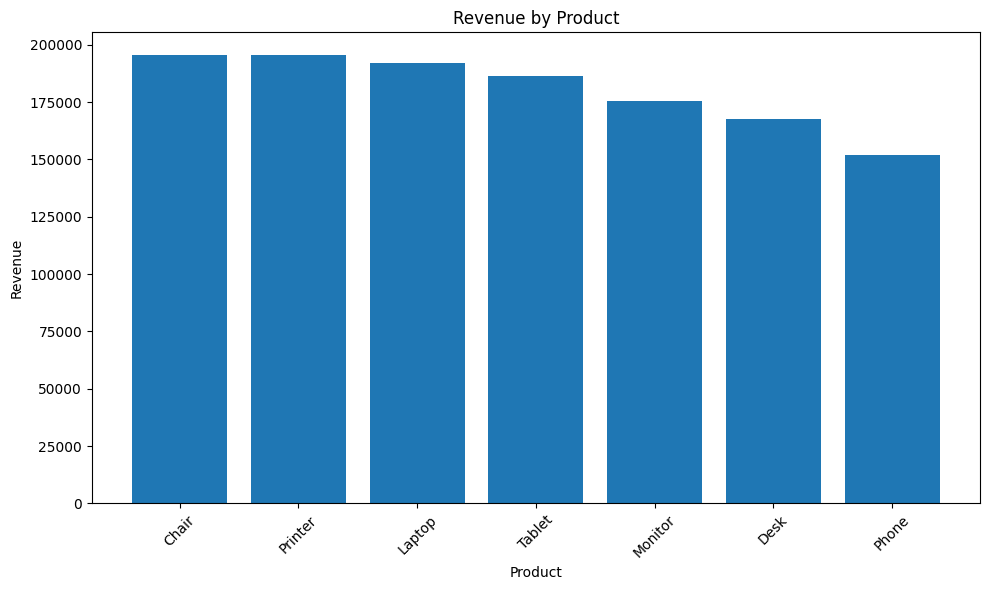

In [21]:
plt.figure(figsize=(10,6))

plt.bar(result5["Product"], result5["Revenue"])

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

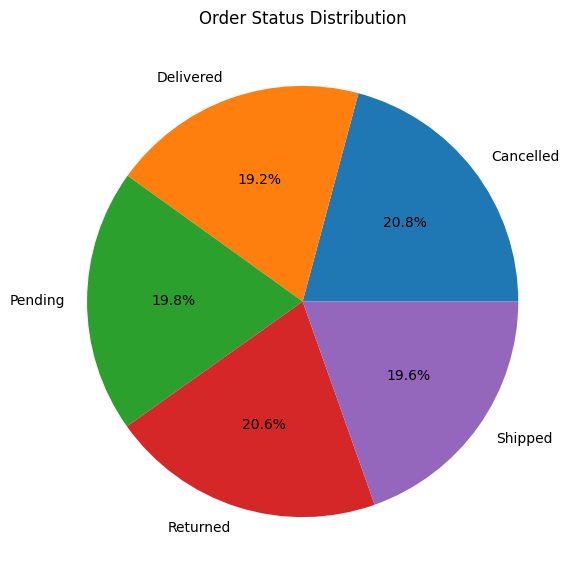

In [22]:
plt.figure(figsize=(7,7))

plt.pie(
    result7["Total"],
    labels=result7["OrderStatus"],
    autopct='%1.1f%%'
)

plt.title("Order Status Distribution")

plt.show()